In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Задание 1

In [2]:
data = pd.read_csv('../DS_07.ID_1187050/datasets/credit_scoring.csv')

In [3]:
data[
    (data['Возраст'] > 18) &
    (data['Месячный доход'] > 10000)
]

,Имя,Возраст,Месячный доход
1,Ольга,43,12000
4,Петр,21,20000


# Задание 2

In [4]:
from sklearn import datasets

In [5]:
iris = datasets.load_iris()

In [6]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [7]:
X = pd.DataFrame(iris['data'], columns=iris['feature_names'])
Y = iris['target']
Y_names = [iris.target_names[x] for x in Y.tolist()]

In [8]:
X.head(2)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2


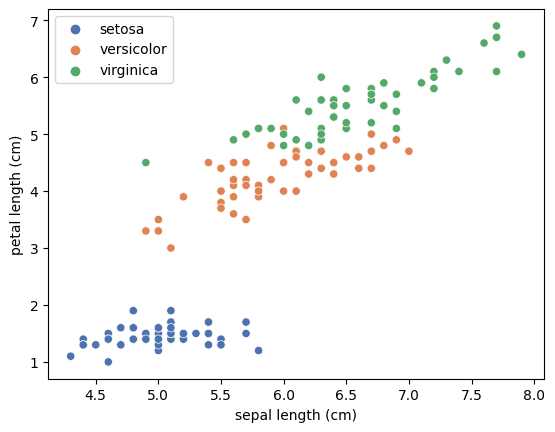

In [9]:
sns.scatterplot(
    x=X['sepal length (cm)'], y=X['petal length (cm)'], hue=Y_names, palette="deep"
);

# Задание 3

In [10]:
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

In [11]:
from matplotlib.colors import ListedColormap

In [12]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X[['sepal length (cm)', 'petal length (cm)']], Y, test_size=0.2, random_state=42
)

In [13]:
X_train

,sepal length (cm),petal length (cm)
22,4.6,1.0
15,5.7,1.5
65,6.7,4.4
11,4.8,1.6
42,4.4,1.3
...,...,...
71,6.1,4.0
106,4.9,4.5
14,5.8,1.2
92,5.8,4.0


In [14]:
clf = DecisionTreeClassifier(max_depth=2)
clf.fit(X_train.to_numpy(), Y_train)

DecisionTreeClassifier(max_depth=2)

In [15]:
predictions = clf.predict(X_test.to_numpy())
round(accuracy_score(Y_test, predictions), 3)

0.967

# Задание 4

In [16]:
def get_meshgrid(data, step=.05, border=.5,):
    x_min, x_max = data[:, 0].min() - border, data[:, 0].max() + border
    y_min, y_max = data[:, 1].min() - border, data[:, 1].max() + border
    return np.meshgrid(np.arange(x_min, x_max, step), np.arange(y_min, y_max, step))

In [17]:
def plot_decision_surface(
    model, train_data, train_labels, test_data, test_labels, 
    colors=ListedColormap(['red', 'blue', 'yellow']), 
    light_colors=ListedColormap(['lightcoral', 'lightblue', 'lightyellow'])
):    
    train_data = train_data.to_numpy()
    test_data = test_data.to_numpy()
    #set figure size
    plt.figure(figsize = (16, 6))
    
    plt.subplot(1, 2, 1)
    xx, yy = get_meshgrid(train_data)
    mesh_predictions = np.array(model.predict(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)

    #plot decision surface on the train data 
    plt.pcolormesh(xx, yy, mesh_predictions, cmap = light_colors)
    plt.scatter(train_data[:, 0], train_data[:, 1], c=train_labels, s=100, cmap=colors)
    plt.title('Train data, accuracy={:.2f}'.format(accuracy_score(train_labels, model.predict(train_data))))
    
    #plot decision surface on the test data
    plt.subplot(1, 2, 2)
    plt.pcolormesh(xx, yy, mesh_predictions, cmap=light_colors)
    plt.scatter(test_data[:, 0], test_data[:, 1], c=test_labels, s=100, cmap=colors)
    plt.title('Test data, accuracy={:.2f}'.format(accuracy_score(test_labels, model.predict(test_data))))

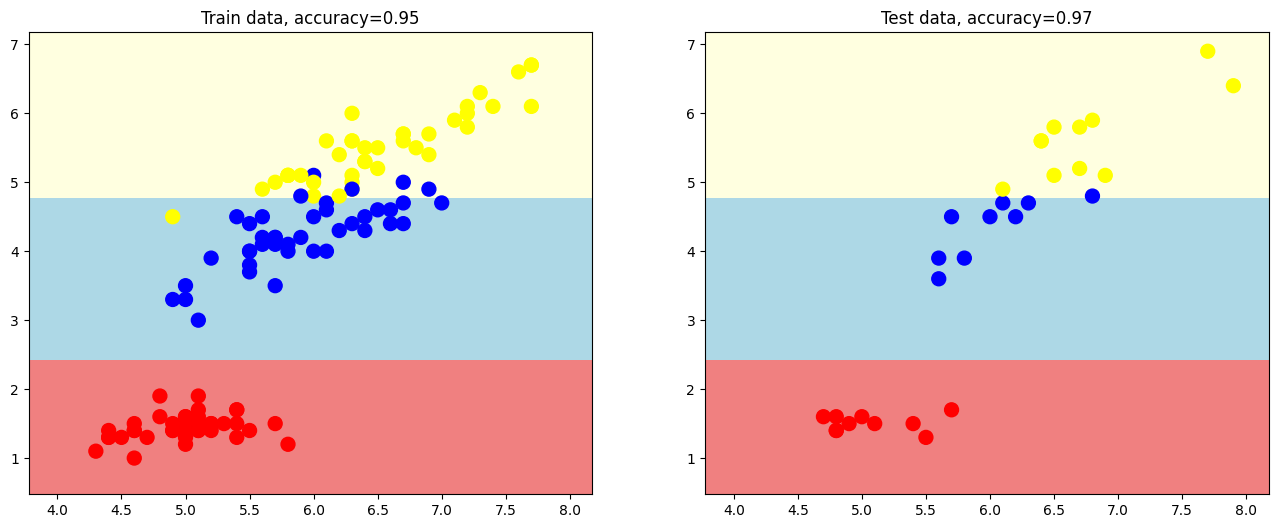

In [18]:
plot_decision_surface(clf, X_train, Y_train, X_test, Y_test)

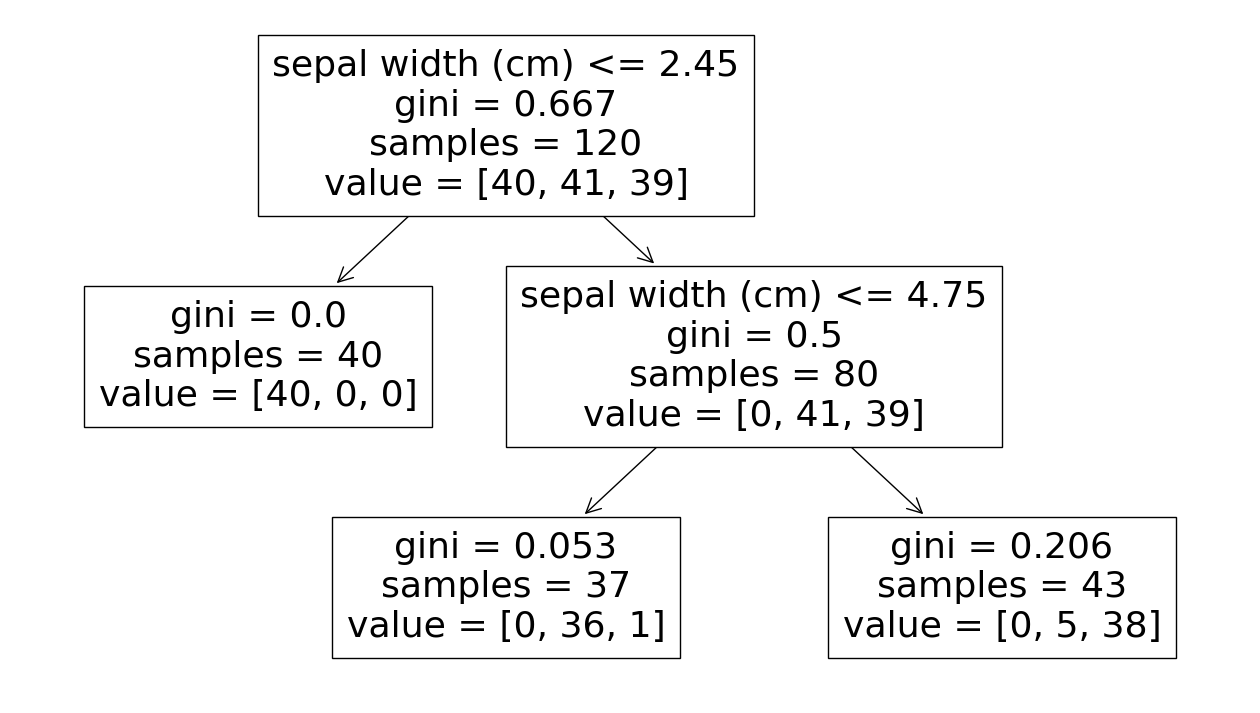

In [19]:
plt.figure(figsize=(16, 9))
plot_tree(clf, feature_names=iris.feature_names)
plt.show()

# Задание 5

In [20]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

In [21]:
def generate_sin(sample_size, n=1):
    np.random.seed(42)
    X = np.random.random((sample_size, n))*3
    coeffs = 1 +  2 * np.random.random((n, 1))
    y = np.sin(np.matmul(X*X, coeffs)) + np.random.random((sample_size, 1))
    return X, y

In [22]:
X, y = generate_sin(1000)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train MSE:  0.382
test MSE:  0.381


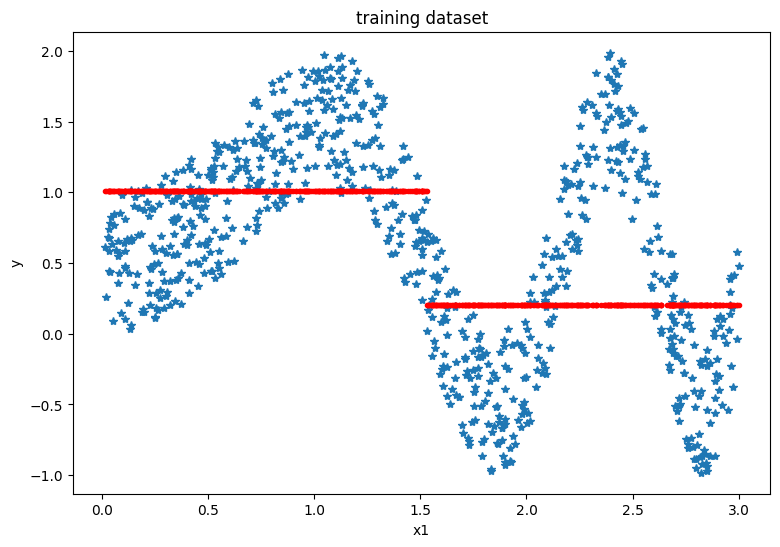

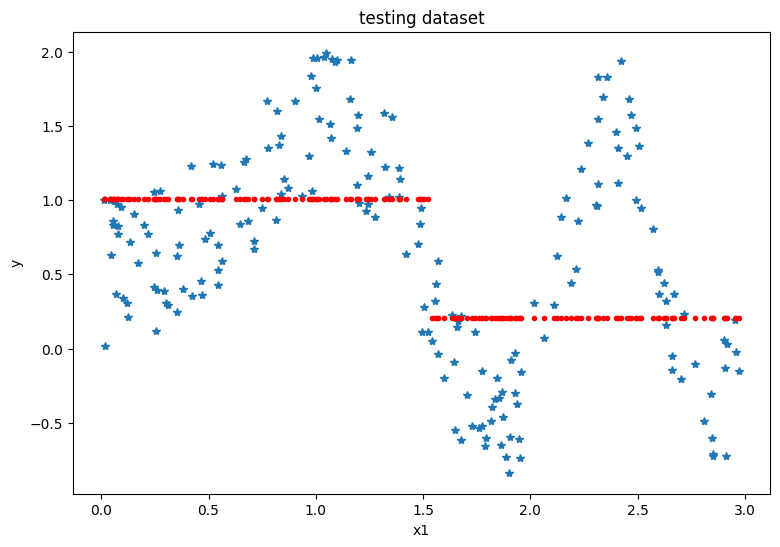

In [24]:
clf = DecisionTreeRegressor(max_depth=1)
clf.fit(X_train, y_train)
print('train MSE: ', round((mean_squared_error(y_train, clf.predict(X_train))), 3))
print('test MSE: ', round(mean_squared_error(y_test, clf.predict(X_test)), 3))

plt.figure(figsize=[9, 6])
plt.plot(X_train, y_train, '*')
plt.plot(X_train, clf.predict(X_train), '.r')
plt.title('training dataset')
plt.xlabel('x1')
plt.ylabel('y')
plt.show()

plt.figure(figsize=[9, 6])
plt.plot(X_test, y_test, '*')
plt.plot(X_test, clf.predict(X_test), '.r')
plt.title('testing dataset')
plt.xlabel('x1')
plt.ylabel('y')
plt.show()

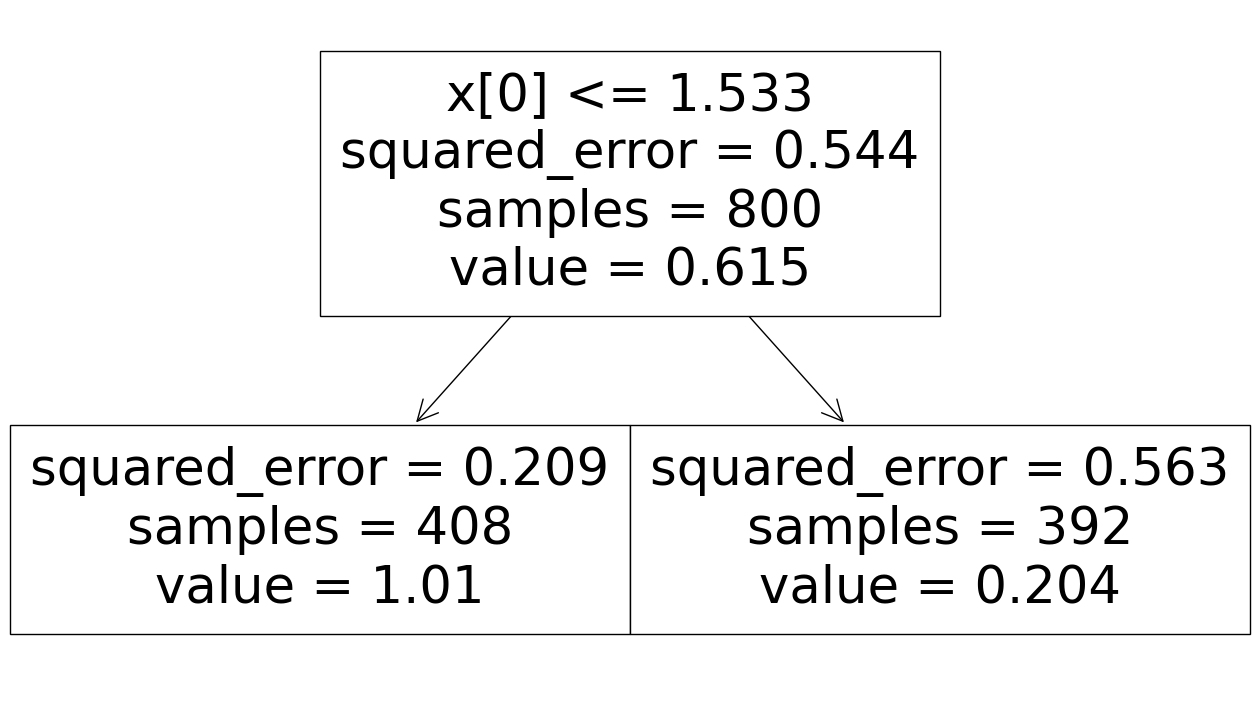

In [25]:
plt.figure(figsize=(16, 9))
plot_tree(clf)
plt.show()

# Задание 6

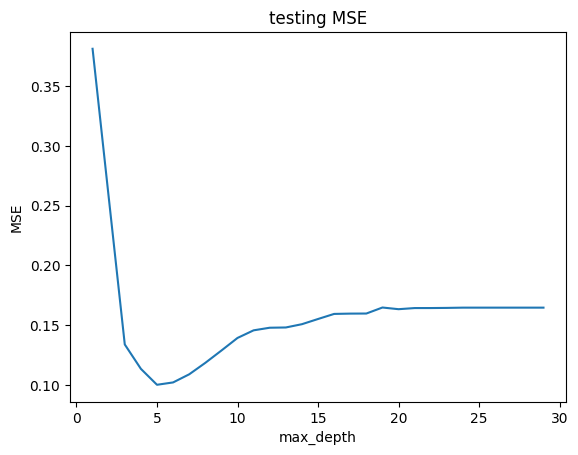

In [26]:
test_mse = []
max_depth_range = range(1, 30)
for md in max_depth_range:
    clf = DecisionTreeRegressor(max_depth=md)
    clf.fit(X_train, y_train)
    test_mse += [mean_squared_error(y_test, clf.predict(X_test))]
plt.plot(max_depth_range, test_mse)
plt.title('testing MSE')
plt.ylabel("MSE")
plt.xlabel('max_depth')
plt.show()

In [27]:
optim_mse = min(list(zip(test_mse, max_depth_range)), key = lambda x: x[0])
print("Best MSE on test with max_depth = {}: {}".format(optim_mse[1], optim_mse[0]))

Best MSE on test with max_depth = 5: 0.10029760373699702


# Задание 7

In [28]:
from sklearn.ensemble import BaggingRegressor

In [29]:
X_train[0]

array([0.13935124])

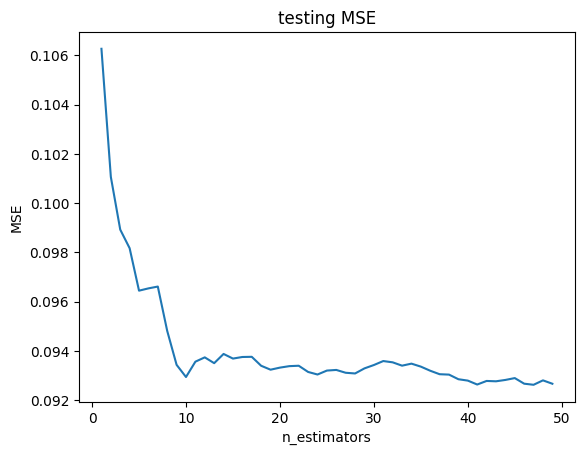

In [30]:
test_mse = []
n_estimators_range = range(1, 50)
for ne in n_estimators_range:
    clf = BaggingRegressor(DecisionTreeRegressor(max_depth=5), n_estimators=ne, bootstrap=True, random_state=42).fit(X_train, y_train.ravel())
    test_mse.append(mean_squared_error(y_test, clf.predict(X_test)))
plt.plot(n_estimators_range, test_mse)
plt.title('testing MSE')
plt.ylabel('MSE')
plt.xlabel('n_estimators')
plt.show()

In [31]:
optim_mse = min(list(zip(test_mse, n_estimators_range)), key = lambda x: x[0])
print("Best MSE on test with n_estimators = {}: {}".format(optim_mse[1], optim_mse[0]))

Best MSE on test with n_estimators = 47: 0.09262002596469604


# Задание 8

In [32]:
from sklearn.ensemble import RandomForestRegressor

In [33]:
clf = RandomForestRegressor(max_depth=5, n_estimators=100, max_features=1, random_state=42)
clf.fit(X_train, y_train.ravel())
print('train MSE: ', mean_squared_error(y_train, clf.predict(X_train)))
print('test MSE: ', mean_squared_error(y_test, clf.predict(X_test)))

train MSE:  0.07304518902397115
test MSE:  0.09076003396323057
